# Scat Feature Extraction Demo: MFCC, Spectral Flux, ZCR

This Colab-style notebook analyzes a monophonic voice/scat input with 10 ms frame features. It is intended as the first front-end prototype for the scat analyzer before mapping syllables such as `ddang`, `ddaeng`, or `ddeung` into Bass-DDSP articulation controls.

Outputs:
- waveform and log spectrogram
- MFCC and delta-MFCC heatmaps
- spectral flux and zero-crossing-rate curves
- onset candidates from spectral flux
- frame feature tensor shaped `(T, C)`

In [1]:
# Colab / local setup
import importlib
import subprocess
import sys

def ensure(package, import_name=None):
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

ensure('librosa')
ensure('soundfile')
ensure('numpy')
ensure('matplotlib')
ensure('scipy')
ensure('pandas')

from pathlib import Path
import io
import math
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from IPython.display import Audio, display

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.22
np.set_printoptions(precision=4, suppress=True)

## 1. Load A Voice Input

In Colab, run this cell and upload a short vocal/scat recording. If no file is uploaded, the notebook synthesizes a small fallback demo signal so all plots still run.

In [2]:
TARGET_SR = 16000

def synthesize_fallback_scat(sr=TARGET_SR):
    rng = np.random.default_rng(7)
    syllables = []
    f0s = [105.0, 138.0, 92.0, 164.0]
    durations = [0.42, 0.36, 0.50, 0.44]
    for i, (f0, dur) in enumerate(zip(f0s, durations)):
        n = int(round(dur * sr))
        t = np.arange(n) / sr
        onset_noise = rng.normal(0, 1, n) * np.exp(-t / 0.018)
        vowel_env = (1.0 - np.exp(-t / 0.035)) * np.exp(-t / 0.65)
        vibrato = 0.012 * np.sin(2 * np.pi * 5.5 * t + i)
        phase = 2 * np.pi * np.cumsum(f0 * (1 + vibrato)) / sr
        harmonic = np.sin(phase) + 0.35 * np.sin(2 * phase + 0.4) + 0.16 * np.sin(3 * phase + 1.1)
        syllable = 0.65 * harmonic * vowel_env + 0.20 * onset_noise
        syllables.append(syllable.astype(np.float32))
        syllables.append(np.zeros(int(0.06 * sr), dtype=np.float32))
    y = np.concatenate(syllables)
    y = y / max(np.max(np.abs(y)), 1e-7) * 0.9
    return y.astype(np.float32), sr, 'synthetic_fallback_scat.wav'

def load_uploaded_or_fallback():
    try:
        from google.colab import files
        uploaded = files.upload()
        if uploaded:
            name, data = next(iter(uploaded.items()))
            y, sr = librosa.load(io.BytesIO(data), sr=TARGET_SR, mono=True)
            return y.astype(np.float32), sr, name
    except Exception as exc:
        print('Upload skipped or unavailable:', exc)
    return synthesize_fallback_scat(TARGET_SR)

y, sr, source_name = load_uploaded_or_fallback()
y, _ = librosa.effects.trim(y, top_db=45)
y = y.astype(np.float32)
y = y / max(np.max(np.abs(y)), 1e-7) * 0.95

print('source:', source_name)
print('sample rate:', sr)
print('duration:', len(y) / sr, 'seconds')
display(Audio(y, rate=sr))

Upload skipped or unavailable: No module named 'google.colab'
source: synthetic_fallback_scat.wav
sample rate: 16000
duration: 1.96 seconds


## 2. Extract 10 ms Frame Features

`hop_length = 10 ms` matches the intended scat analyzer control frame rate. `frame_length = 25 ms` is conventional for short-time voice features.

In [3]:
HOP_SECONDS = 0.010
FRAME_SECONDS = 0.025
N_MFCC = 20

hop_length = int(round(HOP_SECONDS * sr))
win_length = int(round(FRAME_SECONDS * sr))
n_fft = 1
while n_fft < win_length:
    n_fft *= 2

stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length, center=True)
mag = np.abs(stft).astype(np.float32)
power = mag ** 2
times = librosa.frames_to_time(np.arange(mag.shape[1]), sr=sr, hop_length=hop_length)

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=n_fft, hop_length=hop_length, win_length=win_length)
mfcc_delta = librosa.feature.delta(mfcc)
zcr = librosa.feature.zero_crossing_rate(y, frame_length=win_length, hop_length=hop_length, center=True)[0]

# Spectral flux: positive frame-to-frame spectral change after L1 magnitude normalization.
mag_norm = mag / np.maximum(np.sum(mag, axis=0, keepdims=True), 1e-8)
positive_diff = np.maximum(np.diff(mag_norm, axis=1), 0.0)
spectral_flux = np.concatenate([[0.0], np.sqrt(np.sum(positive_diff ** 2, axis=0))]).astype(np.float32)

def robust_normalize(x):
    x = np.asarray(x, dtype=np.float32)
    lo, hi = np.percentile(x, [5, 95])
    return np.clip((x - lo) / max(hi - lo, 1e-7), 0.0, 1.0)

flux_norm = robust_normalize(spectral_flux)
zcr_norm = robust_normalize(zcr)
frame_energy = librosa.feature.rms(S=mag, frame_length=n_fft, hop_length=hop_length, center=True)[0]
energy_norm = robust_normalize(frame_energy)

feature_tensor = np.concatenate([
    mfcc.T,
    mfcc_delta.T,
    zcr[:, None],
    spectral_flux[:, None],
    energy_norm[:, None],
], axis=1).astype(np.float32)

feature_names = (
    [f'mfcc_{i:02d}' for i in range(N_MFCC)]
    + [f'delta_mfcc_{i:02d}' for i in range(N_MFCC)]
    + ['zcr', 'spectral_flux', 'energy_norm']
)

print('hop_length:', hop_length, 'samples')
print('win_length:', win_length, 'samples')
print('n_fft:', n_fft)
print('mfcc:', mfcc.shape, '(coefficients, frames)')
print('zcr:', zcr.shape)
print('spectral_flux:', spectral_flux.shape)
print('feature_tensor:', feature_tensor.shape, '(T, C)')

hop_length: 160 samples
win_length: 400 samples
n_fft: 512
mfcc: (20, 197) (coefficients, frames)
zcr: (197,)
spectral_flux: (197,)
feature_tensor: (197, 43) (T, C)


## 3. Detect Candidate Vocal Transients

These are not final labels. They are visual markers for consonant-like events where a scat classifier may reset or change articulation state.

In [4]:
min_distance_frames = max(1, int(round(0.080 / HOP_SECONDS)))
peaks, properties = find_peaks(
    flux_norm,
    height=0.35,
    prominence=0.10,
    distance=min_distance_frames,
)
peak_times = times[peaks]
print('candidate transient frames:', peaks.tolist())
print('candidate transient times:', np.round(peak_times, 3).tolist())

candidate transient frames: [2, 42, 50, 84, 92, 140, 148, 190]
candidate transient times: [0.02, 0.42, 0.5, 0.84, 0.92, 1.4, 1.48, 1.9]


## 4. Rich Visual Dashboard

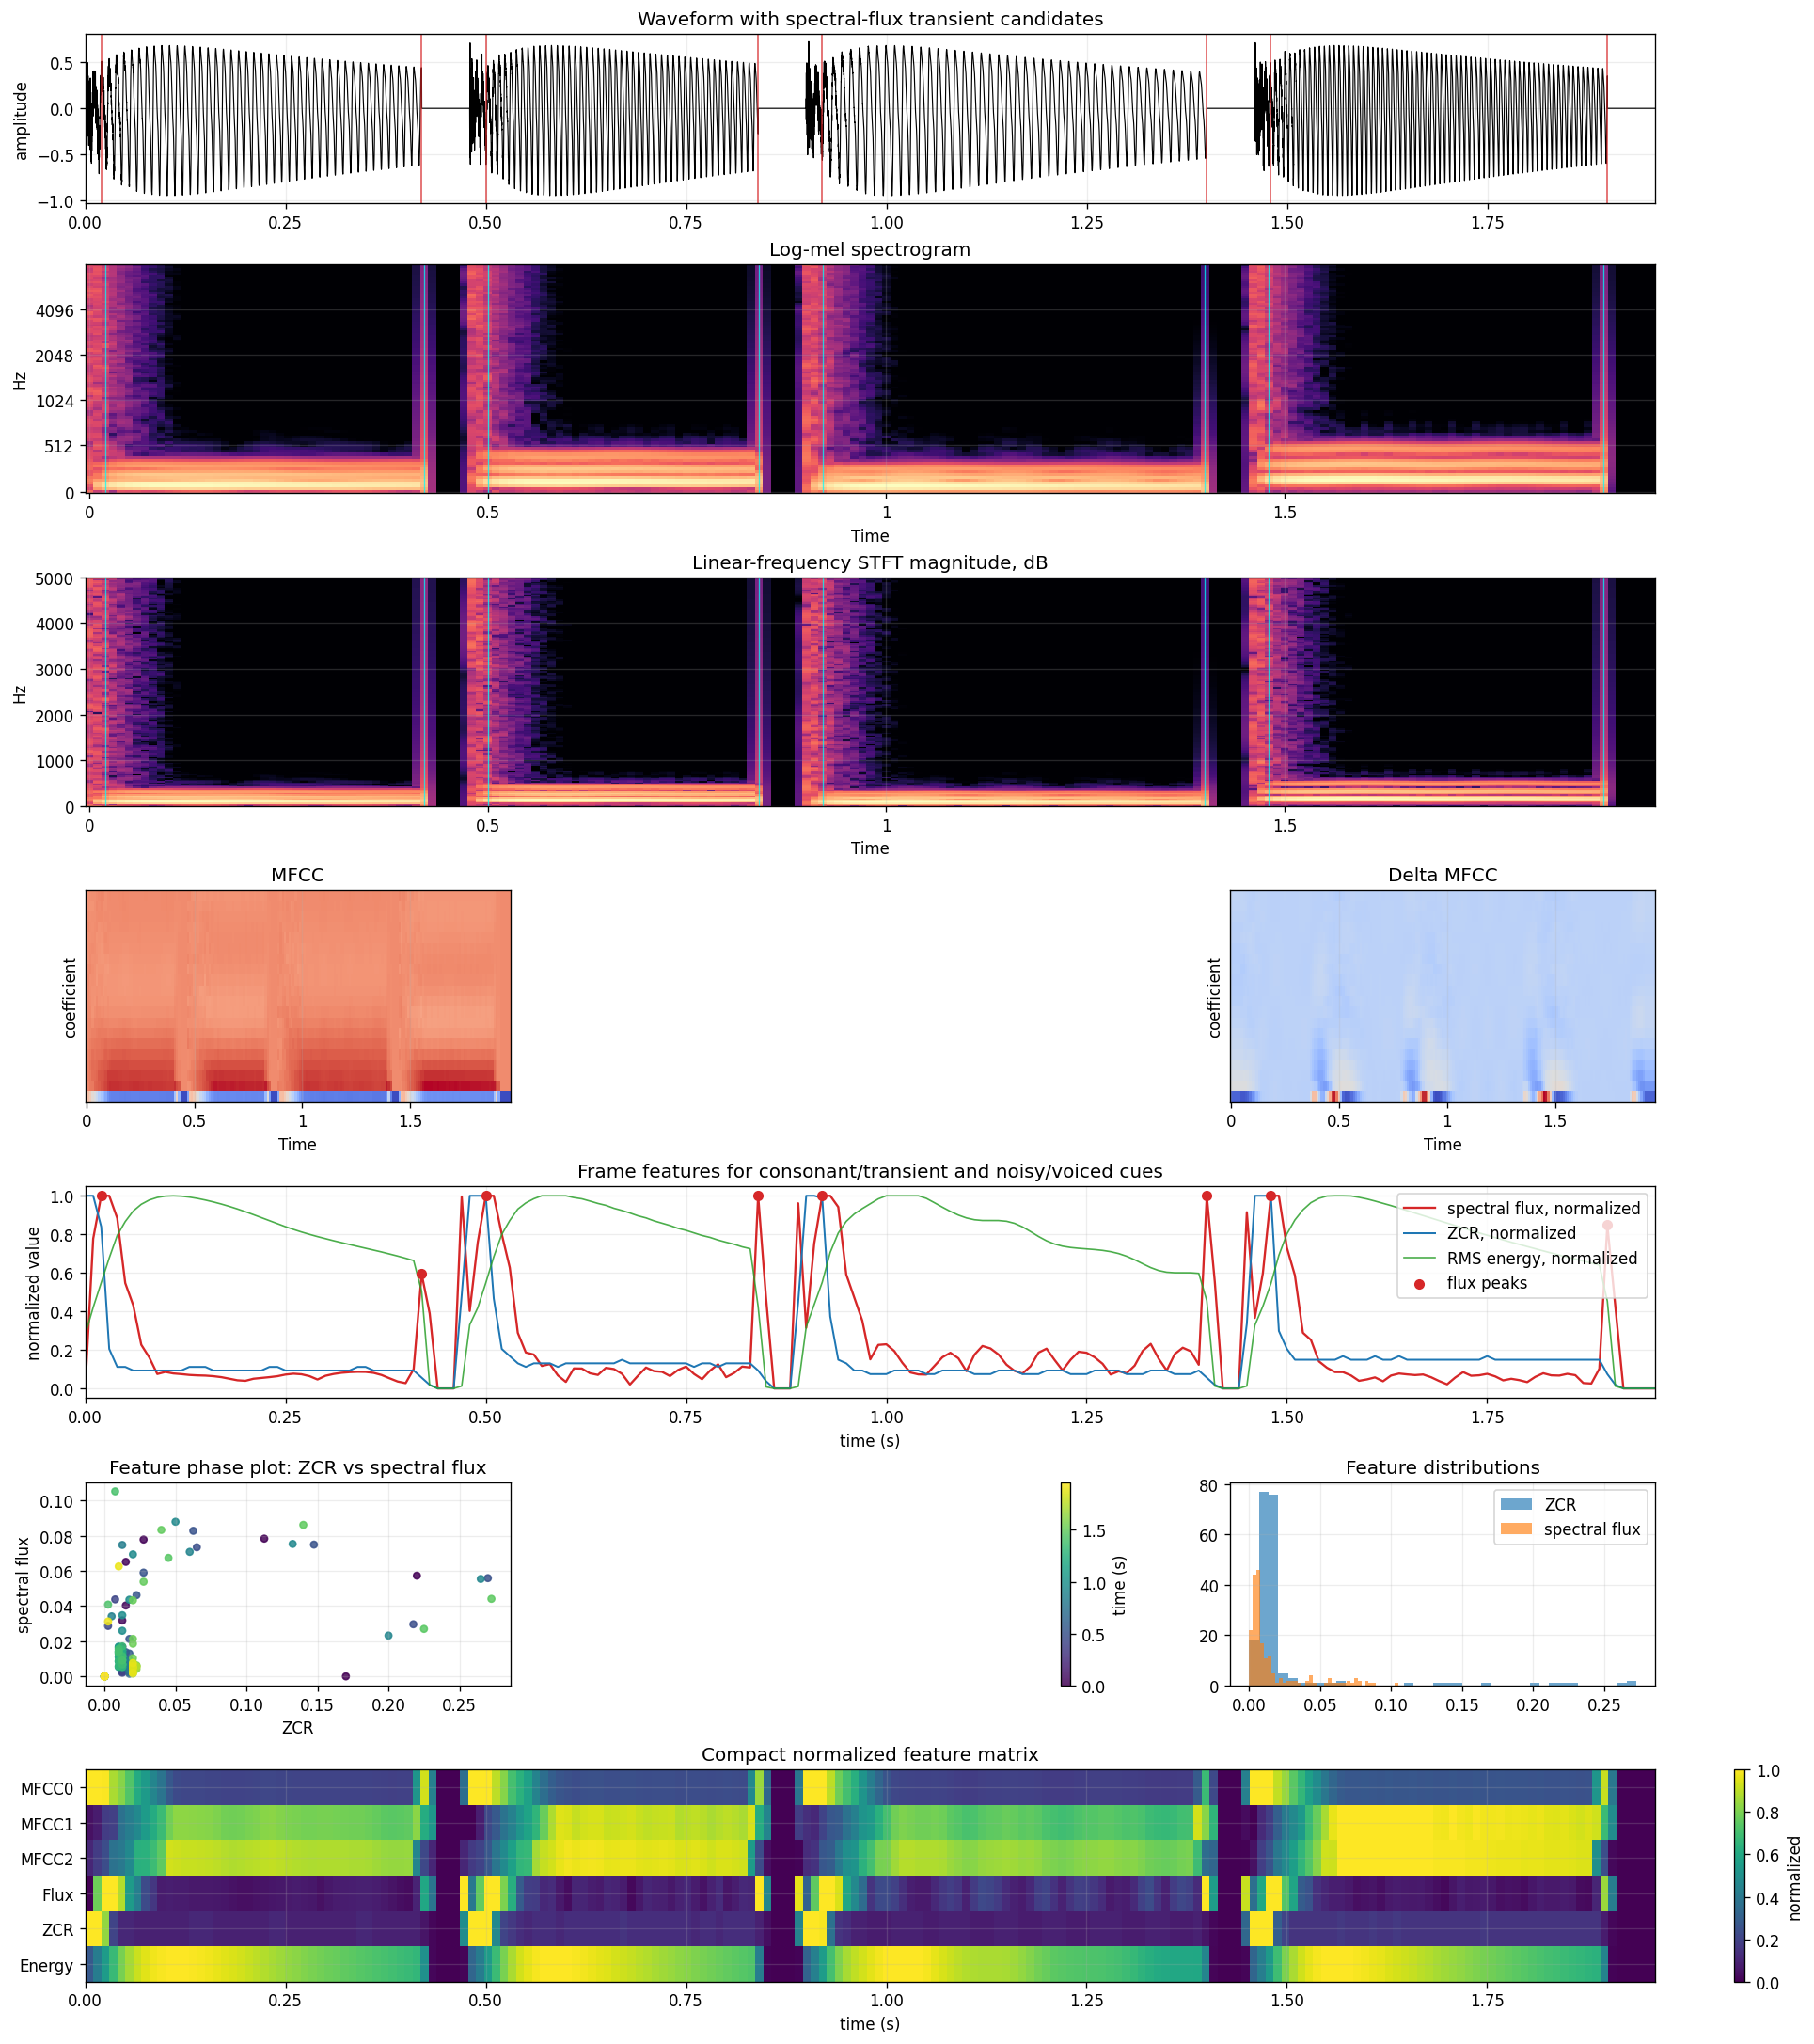

In [5]:
audio_time = np.arange(len(y)) / sr
log_power_db = librosa.power_to_db(power, ref=np.max)
mel_db = librosa.power_to_db(
    librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, win_length=win_length, n_mels=96),
    ref=np.max,
)

fig = plt.figure(figsize=(16, 18), constrained_layout=True)
gs = fig.add_gridspec(7, 2, height_ratios=[1.0, 1.35, 1.35, 1.25, 1.25, 1.2, 1.25])

ax = fig.add_subplot(gs[0, :])
ax.plot(audio_time, y, color='black', linewidth=0.7)
for t in peak_times:
    ax.axvline(t, color='#d62728', alpha=0.75, linewidth=1.0)
ax.set_title('Waveform with spectral-flux transient candidates')
ax.set_ylabel('amplitude')
ax.set_xlim(0, audio_time[-1] if len(audio_time) else 0)

ax = fig.add_subplot(gs[1, :])
librosa.display.specshow(mel_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', cmap='magma', ax=ax)
for t in peak_times:
    ax.axvline(t, color='cyan', alpha=0.75, linewidth=0.8)
ax.set_title('Log-mel spectrogram')

ax = fig.add_subplot(gs[2, :])
librosa.display.specshow(log_power_db, sr=sr, hop_length=hop_length, x_axis='time', y_axis='hz', cmap='magma', ax=ax)
ax.set_ylim(0, min(5000, sr / 2))
for t in peak_times:
    ax.axvline(t, color='cyan', alpha=0.75, linewidth=0.8)
ax.set_title('Linear-frequency STFT magnitude, dB')

ax = fig.add_subplot(gs[3, 0])
librosa.display.specshow(mfcc, x_axis='time', sr=sr, hop_length=hop_length, cmap='coolwarm', ax=ax)
ax.set_title('MFCC')
ax.set_ylabel('coefficient')

ax = fig.add_subplot(gs[3, 1])
librosa.display.specshow(mfcc_delta, x_axis='time', sr=sr, hop_length=hop_length, cmap='coolwarm', ax=ax)
ax.set_title('Delta MFCC')
ax.set_ylabel('coefficient')

ax = fig.add_subplot(gs[4, :])
ax.plot(times, flux_norm, color='#d62728', label='spectral flux, normalized', linewidth=1.4)
ax.plot(times, zcr_norm, color='#1f77b4', label='ZCR, normalized', linewidth=1.2)
ax.plot(times, energy_norm, color='#2ca02c', label='RMS energy, normalized', linewidth=1.0, alpha=0.85)
ax.scatter(peak_times, flux_norm[peaks], color='#d62728', s=32, zorder=3, label='flux peaks')
ax.set_title('Frame features for consonant/transient and noisy/voiced cues')
ax.set_xlabel('time (s)')
ax.set_ylabel('normalized value')
ax.set_xlim(0, times[-1] if len(times) else 0)
ax.legend(loc='upper right')

ax = fig.add_subplot(gs[5, 0])
sc = ax.scatter(zcr, spectral_flux, c=times[:len(zcr)], cmap='viridis', s=18, alpha=0.85)
ax.set_title('Feature phase plot: ZCR vs spectral flux')
ax.set_xlabel('ZCR')
ax.set_ylabel('spectral flux')
fig.colorbar(sc, ax=ax, label='time (s)')

ax = fig.add_subplot(gs[5, 1])
ax.hist(zcr, bins=40, alpha=0.65, label='ZCR')
ax.hist(spectral_flux, bins=40, alpha=0.65, label='spectral flux')
ax.set_title('Feature distributions')
ax.legend()

ax = fig.add_subplot(gs[6, :])
compact = np.vstack([
    robust_normalize(mfcc[0]),
    robust_normalize(mfcc[1]),
    robust_normalize(mfcc[2]),
    flux_norm,
    zcr_norm,
    energy_norm,
])
im = ax.imshow(compact, aspect='auto', interpolation='nearest', cmap='viridis', extent=[times[0], times[-1], compact.shape[0], 0])
ax.set_yticks(np.arange(0.5, 6.5))
ax.set_yticklabels(['MFCC0', 'MFCC1', 'MFCC2', 'Flux', 'ZCR', 'Energy'])
ax.set_xlabel('time (s)')
ax.set_title('Compact normalized feature matrix')
fig.colorbar(im, ax=ax, label='normalized')

plt.show()

## 5. Export `(T, C)` Features

For a future scat classifier, `feature_tensor[t]` is the frame-level vector at time `times[t]`. This can be fed into a GRU/Mamba classifier as `(B, T, C)` after batching.

In [6]:
df = pd.DataFrame(feature_tensor, columns=feature_names)
df.insert(0, 'time_seconds', times[:len(df)])
df['flux_norm'] = flux_norm[:len(df)]
df['zcr_norm'] = zcr_norm[:len(df)]
df['is_flux_peak'] = False
df.loc[peaks[peaks < len(df)], 'is_flux_peak'] = True

out_npz = 'scat_features_10ms.npz'
out_csv = 'scat_features_10ms.csv'
np.savez(
    out_npz,
    y=y,
    sr=sr,
    times=times,
    feature_tensor=feature_tensor,
    feature_names=np.array(feature_names),
    mfcc=mfcc,
    mfcc_delta=mfcc_delta,
    zcr=zcr,
    spectral_flux=spectral_flux,
    flux_peaks=peaks,
)
df.to_csv(out_csv, index=False)

print('Saved:', out_npz)
print('Saved:', out_csv)
print('Classifier input shape after batching would be:', (1, *feature_tensor.shape))
display(df.head(12))

try:
    from google.colab import files
    print('Use files.download(out_npz) or files.download(out_csv) if you want local copies.')
except Exception:
    pass

Saved: scat_features_10ms.npz
Saved: scat_features_10ms.csv
Classifier input shape after batching would be: (1, 197, 43)


,time_seconds,mfcc_00,mfcc_01,mfcc_02,mfcc_03,mfcc_04,mfcc_05,mfcc_06,mfcc_07,mfcc_08,...,delta_mfcc_16,delta_mfcc_17,delta_mfcc_18,delta_mfcc_19,zcr,spectral_flux,energy_norm,flux_norm,zcr_norm,is_flux_peak
0,0.00,-127.765205,8.077298,15.098843,9.847283,13.563171,12.654577,4.998963,1.660432,-5.770354,...,-1.197374,0.530526,1.325508,1.796730,0.1700,0.000000,0.279423,0.000000,1.000000,False
1,0.01,-116.037682,13.019077,25.117846,20.836319,21.226913,12.709578,8.594884,8.381731,1.878371,...,-1.197374,0.530526,1.325508,1.796730,0.2200,0.057313,0.420771,0.777463,1.000000,False
2,0.02,-152.049744,31.009361,33.501137,38.601463,31.408752,25.447824,12.687029,11.101460,3.373496,...,-1.197374,0.530526,1.325508,1.796730,0.1125,0.078371,0.548441,1.000000,0.839552,True
3,0.03,-211.165085,33.124542,53.117867,56.656658,50.798824,32.365311,21.979046,-0.866794,-14.946325,...,-1.197374,0.530526,1.325508,1.796730,0.0275,0.077844,0.677002,1.000000,0.205224,False
4,0.04,-238.657684,65.335022,57.373093,53.891052,44.846718,37.151375,22.044338,12.955398,-0.204083,...,-1.197374,0.530526,1.325508,1.796730,0.0150,0.065152,0.794263,0.883808,0.111940,False
5,0.05,-283.724823,73.846001,66.847153,58.561890,48.864311,40.950706,26.354830,14.641495,8.303471,...,-0.688143,0.920009,1.794567,1.762899,0.0150,0.040325,0.866138,0.547024,0.111940,False
6,0.06,-340.469482,82.751808,89.568069,71.212784,49.635895,38.968201,35.313450,18.509747,3.525884,...,0.247505,1.044206,1.719728,1.137131,0.0125,0.031799,0.920973,0.431364,0.093284,False
7,0.07,-373.903778,95.615051,90.127533,77.496002,52.909779,46.322952,30.602692,22.162891,-1.130762,...,0.527892,0.410397,1.083932,0.739852,0.0125,0.016734,0.955746,0.227004,0.093284,False
8,0.08,-418.499817,107.105698,97.126091,85.372910,67.783981,50.797947,30.902485,12.973465,0.602941,...,0.390560,-0.004860,0.116985,0.321871,0.0125,0.011882,0.977998,0.161182,0.093284,False
9,0.09,-452.810181,118.996071,106.180473,84.948074,74.861229,56.739162,31.281643,11.455387,-5.057306,...,0.553039,-0.435050,-0.363177,-0.317409,0.0125,0.005541,0.991317,0.075167,0.093284,False


## Notes For The Scat Analyzer

- MFCCs mainly represent vocal tract/timbre shape, useful for vowel-like states.
- Spectral flux emphasizes sudden spectral changes, useful for consonants and syllable onsets.
- ZCR is high for noisy/unvoiced consonants and breathy attacks.
- The first practical classifier target should be framewise or segmentwise syllable/articulation probabilities, not direct waveform synthesis.
- For real-time use, keep the same hop size and use causal feature extraction or a small lookahead buffer.